# Quantum Multiclass Classification

In [17]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


```mermaid
flowchart TD
    A[("Dataset_TehHijau.csv")] --> B[Load data]
    B --> C[Pilih fitur<br/>12 sensor + Humidity + Celsius]
    B --> D[Target: Kategori]

    C --> E[X = features]
    D --> F[y = LabelEncoder]

    E --> G[PCA variance analysis<br/>threshold 95% → n_optimal]

    E --> LOOP
    F --> LOOP
    G --> LOOP

    subgraph LOOP["Loop tiap model + best params"]
        direction TB

        subgraph CV["StratifiedKFold 5-fold CV<br/>shuffle, random_state=42"]
            direction TB
            SPLIT{{"Split per fold<br/>train_idx / val_idx"}}
            SPLIT -->|X_train, y_train| P1[StandardScaler.fit_transform]
            SPLIT -->|X_val, y_val| P4

            P1 --> P2[PCA n_components=n_optimal]
            P2 --> RS[["SMOTEENN Sampling<br/>(train fold only)"]]
            RS --> P3[Classifier.fit]

            P3 --> P4[predict + predict_proba<br/>pada X_val asli]
            P4 --> P5[Metrik per fold:<br/>Acc, F1, ROC-AUC, PR-AUC,<br/>Precision, Recall, Log-Loss]
        end

        CV --> SC[Skor = AUROC+PRAUC+Acc / 3]
        SC --> BEST[Simpan best_result + OOF preds]
        BEST --> CSV[(results/best_param/*.csv)]
        BEST --> AB[all_best.append]
    end

    

    AB --> T[Tabel evaluasi akhir<br/>metrik mean±std]
    T --> O1[(eval_classical_final_hpo.csv)]
    AB --> CM[Confusion Matrix OOF<br/>+ per-class metrics]
    CM --> O2[(confusion_matrix_classical_hpo.png)]
    AB --> LC[Learning Curve<br/>acc / prec / rec / f1 / log-loss]
```

## Utility Function

In [18]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/ml/best_param")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"classical_{name}_hpo.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [19]:
import sys
import os
import pandas as pd
import warnings
from qiskit.transpiler import generate_preset_pass_manager
import sys
import importlib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("quantum-multiclass-classification")[0] + "quantum-multiclass-classification"
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

# Test import module
from utils.prepare_data import prepare_data

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

Project root: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification


## 1. Load & Split Dataset

In [20]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

### 1.1 Exploratory Data Analysis

In [21]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [22]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

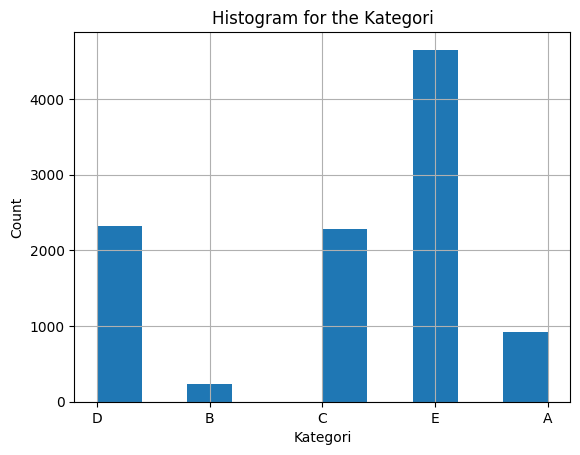

In [23]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

### 1.2 Split Data

In [24]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


### 1.3 Encode Categorical Data (y = Kategori)

In [25]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

### 1.4 PCA Variance Analysis (threshold = 0.95)

In [26]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

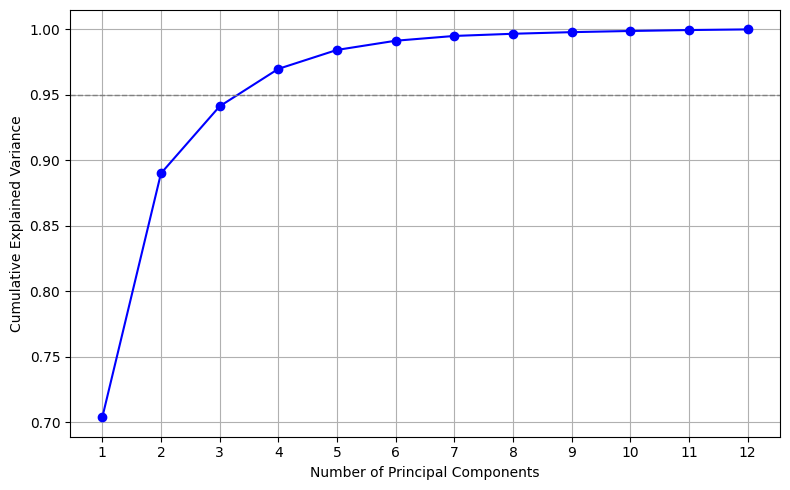

Optimal number of components to retain 95% variance: 4


In [27]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.95)

### 1.5 Komposisi Dataset (Sebelum vs Sesudah SMOTEENN)

Data di-oversampling pakai SMOTE dulu, trus nanti kan pasti ada noise, itu dibersihin pake ENN. ENN ini konsepnya ngecek tetangga terdekat dari data sintesis maupun data asli itu banyak yg sama atau nggak, misal datanya kelass B. Tetangganya mayoritas kelas B atau tidak. Kalau minoritas berarti dibuang. Kalau mayoritas disimpan

Komposisi kelas (full data, ilustrasi):


,Sebelum,Sesudah,Δ
A,927,4601,3674
B,229,4649,4420
C,2287,4519,2232
D,2317,4543,2226
E,4649,4517,-132
TOTAL,10409,22829,12420


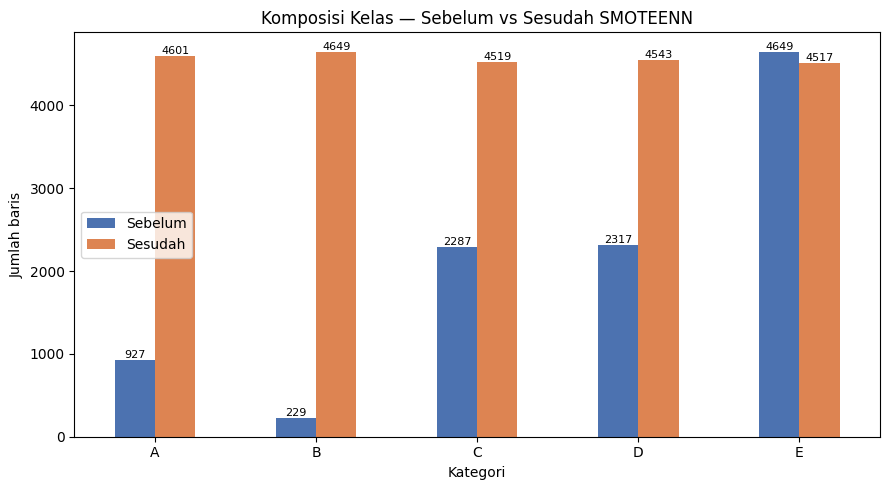

✅ Saved: ./results/composition_before_after_smoteenn.png


In [28]:
# ════════════════════════════════════════════════════════════
# 🔁 Komposisi kelas: SEBELUM vs SESUDAH SMOTEENN
# ════════════════════════════════════════════════════════════
# SMOTEENN diterapkan di ruang (StandardScaler → PCA), sama seperti di dalam CV.
# Di CV resampling hanya pada fold training; di sini full data dipakai semata
# sebagai ILUSTRASI efek resampling terhadap komposisi kelas.
from collections import Counter
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

class_names = list(label_encoder.classes_)

_Xp = PCA(n_components=n_optimal).fit_transform(StandardScaler().fit_transform(X))
_Xr, _yr = SMOTEENN(random_state=42).fit_resample(_Xp, y)

_before, _after = Counter(y), Counter(_yr)
comp = pd.DataFrame({
    "Sebelum": [int(_before.get(i, 0)) for i in range(len(class_names))],
    "Sesudah": [int(_after.get(i, 0)) for i in range(len(class_names))],
}, index=class_names)
comp["Δ"] = comp["Sesudah"] - comp["Sebelum"]
comp.loc["TOTAL"] = comp.sum()
print("Komposisi kelas (full data, ilustrasi):")
display(comp)

ax = comp.drop(index="TOTAL")[["Sebelum", "Sesudah"]].plot(
    kind="bar", figsize=(9, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Komposisi Kelas — Sebelum vs Sesudah SMOTEENN")
ax.set_xlabel("Kategori"); ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.tight_layout()
import os
os.makedirs("./results", exist_ok=True)
plt.savefig("./results/composition_before_after_smoteenn.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Saved: ./results/composition_before_after_smoteenn.png")

## 2. Model Evaluation

### 2.0 Pipeline runner

In [29]:
# Satu fungsi untuk seluruh pipeline CV + logging + simpan CSV + collect best.
import os
import time
import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline          # imblearn Pipeline: sampler aktif HANYA saat .fit
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    precision_score, recall_score, log_loss, classification_report,
)


def make_resampler():
    """SMOTEENN baru tiap fold (di-fit ulang). Resample HANYA fold training -> no leak."""
    return SMOTEENN(random_state=42)


def evaluate_cv(model_name, log_name, search_space, build_clf, csv_name,
               n_splits=5, state=42, results_dir="./results/best_param/"):
    """Jalankan grid CV untuk satu model lalu rekam best config ke `all_best`.

    Pipeline per fold: StandardScaler -> PCA -> SMOTEENN (train fold) -> classifier.
    Imbalance ditangani SMOTEENN, jadi TIDAK ada class_weight/sample_weight balancing.

    Memakai global: X, y, n_optimal, all_best, log, setup_logger.
    Mengembalikan best_result (juga sudah di-append ke all_best).
    """
    setup_logger(log_name)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)
    classes = np.unique(y)

    param_keys = list(search_space.keys())
    param_vals = list(search_space.values())
    sizes = {k: len(v) for k, v in search_space.items()}
    total_configs = int(np.prod([len(v) for v in param_vals]))
    total_fits = total_configs * skf.get_n_splits()
    space_str = " × ".join(f"{sizes[k]} {k}" for k in sizes)

    log(f"\U0001f52c Search space: {space_str} =  {total_configs} configs × "
        f"{skf.get_n_splits()} folds = {total_fits} fits")
    log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)")

    best_score = -np.inf
    best_result = None
    results = []

    for i, comb in enumerate(product(*param_vals)):
        params = dict(zip(param_keys, comb))
        tag = " | ".join(f"{k}={v}" for k, v in params.items())
        log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
        t0 = time.perf_counter()

        accs, f1s, rocs, pras, precs, recs, losses = [], [], [], [], [], [], []
        y_val_all, y_pred_all = [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=n_optimal)),
                ("smoteenn", make_resampler()),     # train-fold only (no leak)
                ("clf", build_clf(params)),
            ])
            model.fit(X_train, y_train)

            y_pred = model.predict(X_val)
            y_prob = model.predict_proba(X_val)
            if model_name.lower().startswith("catboost"):
                y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)

            y_val_all.extend(y_val)
            y_pred_all.extend(y_pred)

            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average="macro")
            roc = roc_auc_score(y_val, y_prob, average="weighted", multi_class="ovr")
            pra = average_precision_score(y_val, y_prob, average="weighted")
            prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
            rec = recall_score(y_val, y_pred, average="macro")
            ll = log_loss(y_val, y_prob, labels=classes)

            accs.append(acc); f1s.append(f1); rocs.append(roc)
            pras.append(pra); precs.append(prec); recs.append(rec); losses.append(ll)

            log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | "
                f"F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f} | Loss={ll:.4f}")

            results.append({
                "tag": tag, **params, "fold": fold,
                "accuracy": acc, "precision": prec, "recall": rec,
                "F1": f1, "auroc": roc, "prauc": pra, "loss": ll,
            })

        # Aggregate (mean ± std across folds)
        acc_mean, acc_std = np.mean(accs), np.std(accs)
        prec_mean, prec_std = np.mean(precs), np.std(precs)
        rec_mean, rec_std = np.mean(recs), np.std(recs)
        f1_mean, f1_std = np.mean(f1s), np.std(f1s)
        roc_mean, roc_std = np.mean(rocs), np.std(rocs)
        pra_mean, pra_std = np.mean(pras), np.std(pras)
        loss_mean, loss_std = np.mean(losses), np.std(losses)
        mcc = matthews_corrcoef(y_val_all, y_pred_all)

        composite = (roc_mean + pra_mean + acc_mean) / 3

        log(
            f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
            f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
            f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
            f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
            f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
            f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
            f"Loss:{loss_mean:.4f}±{loss_std:.4f} | "
            f"MCC:{mcc:.4f} | "
            f"Composite:{composite:.4f}"
        )

        iter_time = time.perf_counter() - t0
        if composite > best_score:
            best_score = composite
            best_result = {
                "tag": tag,
                "composite": composite,
                "acc": f"{acc_mean:.4f}±{acc_std:.4f}",
                "prec": f"{prec_mean:.4f}±{prec_std:.4f}",
                "rec": f"{rec_mean:.4f}±{rec_std:.4f}",
                "f1": f"{f1_mean:.4f}±{f1_std:.4f}",
                "roc": f"{roc_mean:.4f}±{roc_std:.4f}",
                "pra": f"{pra_mean:.4f}±{pra_std:.4f}",
                "loss": f"{loss_mean:.4f}±{loss_std:.4f}",
                "mcc": f"{mcc:.4f}",
                "params": params,
                "execution_time": iter_time,
                # OOF preds best config -> dipakai confusion matrix & per-class metrics
                "y_true": list(y_val_all),
                "y_pred": list(y_pred_all),
            }

    log(f"\n\U0001f3c6 Best config : {best_result['tag']}")
    log(
        f"   Composite   : {best_result['composite']:.4f} "
        f"(AUROC={best_result['roc']} | "
        f"PRAUC={best_result['pra']} | "
        f"Acc={best_result['acc']} |"
        f"Prec={best_result['prec']} |"
        f"Rec={best_result['rec']} |"
        f"Loss={best_result['loss']})"
    )

    # -- Simpan hasil per-fold --
    os.makedirs(results_dir, exist_ok=True)
    filename = os.path.join(results_dir, csv_name)
    pd.DataFrame(results).to_csv(filename, index=False)
    log(f"✅ Saved: {filename}")

    # -- Collect best result --
    best_result["model"] = model_name
    # -- Per-class metrics (OOF, best config) via classification_report --
    _cls_names = [str(c) for c in label_encoder.classes_]
    best_result["report_text"] = classification_report(
        best_result["y_true"], best_result["y_pred"],
        labels=classes, target_names=_cls_names, zero_division=0)
    best_result["report_dict"] = classification_report(
        best_result["y_true"], best_result["y_pred"],
        labels=classes, target_names=_cls_names, output_dict=True, zero_division=0)
    log("")
    log("=" * 60)
    log(f"📋 Classification report (OOF, best config) — {model_name}:")
    log("=" * 60)
    log(best_result["report_text"])
    all_best.append(dict(best_result))
    log(f"✅ [{model_name}] recorded | Exec. time: {best_result['execution_time']:.1f}s")

    return best_result


def build_eval_table(all_best):
    """Tabel evaluasi: row = model, column = metrik (mean±std)."""
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Log-Loss'       : r.get('loss', 'N/A'),
            'MCC'            : r.get('mcc', 'N/A'),
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df


# ── Factory: rekonstruksi pipeline dari (model_name, best_params) ────────────
# Pipeline identik dengan evaluate_cv (Scaler → PCA → SMOTEENN → clf) supaya
# learning curve mencerminkan training yang sebenarnya.
def make_classical(model_name, params):
    # decision_function_shape di-hardcode "ovr" untuk SVC di bawah; buang dari
    # best_params (RBF/Sigmoid menyimpannya) agar tidak bentrok ("got multiple values").
    params = {k: v for k, v in params.items() if k != "decision_function_shape"}
    base = [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_optimal)),
        ("smoteenn", make_resampler()),
    ]
    if   model_name == "SVC Linear":
        clf = SVC(kernel="linear",  probability=True, random_state=42,
                  decision_function_shape="ovr", **params)
    elif model_name == "SVC Poly":
        clf = SVC(kernel="poly",    probability=True, random_state=42,
                  decision_function_shape="ovr", **params)
    elif model_name == "SVC RBF":
        clf = SVC(kernel="rbf",     probability=True, random_state=42,
                  decision_function_shape="ovr", **params)
    elif model_name == "SVC Sigmoid":
        clf = SVC(kernel="sigmoid", probability=True, random_state=42,
                  decision_function_shape="ovr", **params)
    elif model_name == "XGBoost GBTree":
        clf = XGBClassifier(booster="gbtree", objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "XGBoost Dart":
        clf = XGBClassifier(booster="dart",  objective="multi:softprob",
                                 random_state=42, **params)
    elif model_name == "CatBoost":
        clf = CatBoostClassifier(
            loss_function="MultiClassOneVsAll",
            eval_metric="Accuracy",
            verbose=0,
            random_seed=42,
            task_type="GPU",
            **params,
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")
    base.append(("clf", clf))
    return Pipeline(base)

### 2.1 SVC Linear

In [30]:
search_space = {
    "C": [0.1],
    # "tol": [0.1],
}
evaluate_cv(
    model_name="SVC Linear",
    log_name="svc_linear",
    search_space=search_space,
    build_clf=lambda p: SVC(kernel="linear", probability=True, random_state=42,
                            decision_function_shape="ovr", **p),
    csv_name="svc_linear_hpo.csv",
)

📝 Log: results\logs\ml\best_param\classical_svc_linear_hpo.log
🕒 Started: 2026-06-08T07:09:59
🔬 Search space: 1 C =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] C=0.1
    F1 → Acc=0.3939 | Prec=0.4196 | Rec=0.5072 | F1=0.3660 | AUROC=0.7024 | PRAUC=0.4879 | Loss=1.2821
    F2 → Acc=0.4030 | Prec=0.4294 | Rec=0.5247 | F1=0.3740 | AUROC=0.7170 | PRAUC=0.5044 | Loss=1.2520
    F3 → Acc=0.3866 | Prec=0.4110 | Rec=0.5065 | F1=0.3600 | AUROC=0.6923 | PRAUC=0.4828 | Loss=1.2891
    F4 → Acc=0.4135 | Prec=0.4272 | Rec=0.5423 | F1=0.3897 | AUROC=0.7012 | PRAUC=0.4947 | Loss=1.2479
    F5 → Acc=0.3806 | Prec=0.4105 | Rec=0.5188 | F1=0.3583 | AUROC=0.6966 | PRAUC=0.4854 | Loss=1.2758
  ✅  Acc:0.3955±0.0117 | Precision:0.4195±0.0079  |Recall:0.5199±0.0132 |F1:0.3696±0.0115 | AUROC:0.7019±0.0084 | PRAUC:0.4910±0.0078 | Loss:1.2694±0.0165 | MCC:0.2688 | Composite:0.5295

🏆 Best config : C=0.1
   Composite   : 0

{'tag': 'C=0.1',
 'composite': np.float64(0.5294921330158434),
 'acc': '0.3955±0.0117',
 'prec': '0.4195±0.0079',
 'rec': '0.5199±0.0132',
 'f1': '0.3696±0.0115',
 'roc': '0.7019±0.0084',
 'pra': '0.4910±0.0078',
 'loss': '1.2694±0.0165',
 'mcc': '0.2688',
 'params': {'C': 0.1},
 'execution_time': 249.53073519997997,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(

### 2.2 SVC Poly

In [31]:
search_space = {
    "C": [0.01],
    # "tol": [0.1],
    "degree": [2],
    "gamma": ['scale'],
    # "coef0": [3],
}
evaluate_cv(
    model_name="SVC Poly",
    log_name="svc_poly",
    search_space=search_space,
    build_clf=lambda p: SVC(kernel="poly", probability=True, random_state=42, **p),
    csv_name="svc_poly_hpo.csv",
)

📝 Log: results\logs\ml\best_param\classical_svc_poly_hpo.log
🕒 Started: 2026-06-08T07:14:08
🔬 Search space: 1 C × 1 degree × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] C=0.01 | degree=2 | gamma=scale
    F1 → Acc=0.4616 | Prec=0.4910 | Rec=0.5284 | F1=0.4225 | AUROC=0.7741 | PRAUC=0.6215 | Loss=1.1736
    F2 → Acc=0.4573 | Prec=0.5024 | Rec=0.5319 | F1=0.4272 | AUROC=0.7871 | PRAUC=0.6435 | Loss=1.1497
    F3 → Acc=0.4486 | Prec=0.5043 | Rec=0.5188 | F1=0.4236 | AUROC=0.7801 | PRAUC=0.6323 | Loss=1.1568
    F4 → Acc=0.4500 | Prec=0.4975 | Rec=0.5244 | F1=0.4258 | AUROC=0.7687 | PRAUC=0.6122 | Loss=1.1612
    F5 → Acc=0.4426 | Prec=0.4966 | Rec=0.5309 | F1=0.4170 | AUROC=0.7793 | PRAUC=0.6207 | Loss=1.1547
  ✅  Acc:0.4520±0.0067 | Precision:0.4984±0.0047  |Recall:0.5269±0.0048 |F1:0.4232±0.0035 | AUROC:0.7779±0.0062 | PRAUC:0.6260±0.0108 | Loss:1.1592±0.0081 | MCC:0.3179 | Composite:0.6

{'tag': 'C=0.01 | degree=2 | gamma=scale',
 'composite': np.float64(0.6186414418347628),
 'acc': '0.4520±0.0067',
 'prec': '0.4984±0.0047',
 'rec': '0.5269±0.0048',
 'f1': '0.4232±0.0035',
 'roc': '0.7779±0.0062',
 'pra': '0.6260±0.0108',
 'loss': '1.1592±0.0081',
 'mcc': '0.3179',
 'params': {'C': 0.01, 'degree': 2, 'gamma': 'scale'},
 'execution_time': 247.95505240000784,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3)

### 2.3 SVC RBF

In [32]:
search_space = {
    "C": [0.05],
    # "tol": [0.1],
    "gamma": ['scale'],
}
evaluate_cv(
    model_name="SVC RBF",
    log_name="svc_rbf",
    search_space=search_space,
    build_clf=lambda p: SVC(kernel="rbf", probability=True, random_state=42,
                            decision_function_shape="ovr", **p),
    csv_name="svc_rbf_hpo.csv",
)

📝 Log: results\logs\ml\best_param\classical_svc_rbf_hpo.log
🕒 Started: 2026-06-08T07:18:16
🔬 Search space: 1 C × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] C=0.05 | gamma=scale
    F1 → Acc=0.7099 | Prec=0.7143 | Rec=0.8013 | F1=0.7240 | AUROC=0.9370 | PRAUC=0.8675 | Loss=0.5511
    F2 → Acc=0.7411 | Prec=0.7411 | Rec=0.8293 | F1=0.7585 | AUROC=0.9414 | PRAUC=0.8780 | Loss=0.5308
    F3 → Acc=0.7373 | Prec=0.7572 | Rec=0.8209 | F1=0.7624 | AUROC=0.9408 | PRAUC=0.8745 | Loss=0.5379
    F4 → Acc=0.7325 | Prec=0.7475 | Rec=0.8246 | F1=0.7561 | AUROC=0.9384 | PRAUC=0.8711 | Loss=0.5437
    F5 → Acc=0.7198 | Prec=0.7382 | Rec=0.8069 | F1=0.7440 | AUROC=0.9258 | PRAUC=0.8423 | Loss=0.5971
  ✅  Acc:0.7281±0.0116 | Precision:0.7397±0.0143  |Recall:0.8166±0.0107 |F1:0.7490±0.0139 | AUROC:0.9367±0.0057 | PRAUC:0.8667±0.0127 | Loss:0.5521±0.0235 | MCC:0.6578 | Composite:0.8438

🏆 Best config : C=

{'tag': 'C=0.05 | gamma=scale',
 'composite': np.float64(0.8438250799295934),
 'acc': '0.7281±0.0116',
 'prec': '0.7397±0.0143',
 'rec': '0.8166±0.0107',
 'f1': '0.7490±0.0139',
 'roc': '0.9367±0.0057',
 'pra': '0.8667±0.0127',
 'loss': '0.5521±0.0235',
 'mcc': '0.6578',
 'params': {'C': 0.05, 'gamma': 'scale'},
 'execution_time': 246.8511381999706,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int

### 2.4 SVC Sigmoid

In [33]:
search_space = {
    "C": [0.1],
    # "tol": [0.1],
    "gamma": ['scale'],
    "coef0": [0],
}
evaluate_cv(
    model_name="SVC Sigmoid",
    log_name="svc_sigmoid",
    search_space=search_space,
    build_clf=lambda p: SVC(kernel="sigmoid", probability=True, random_state=42,
                            decision_function_shape="ovr", **p),
    csv_name="svc_sigmoid_hpo.csv",
)

📝 Log: results\logs\ml\best_param\classical_svc_sigmoid_hpo.log
🕒 Started: 2026-06-08T07:22:23
🔬 Search space: 1 C × 1 gamma × 1 coef0 =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] C=0.1 | gamma=scale | coef0=0
    F1 → Acc=0.1796 | Prec=0.2330 | Rec=0.2408 | F1=0.1713 | AUROC=0.6315 | PRAUC=0.3802 | Loss=1.5140
    F2 → Acc=0.1873 | Prec=0.2577 | Rec=0.2590 | F1=0.1807 | AUROC=0.6478 | PRAUC=0.3880 | Loss=1.5000
    F3 → Acc=0.1686 | Prec=0.2325 | Rec=0.2195 | F1=0.1649 | AUROC=0.6213 | PRAUC=0.3724 | Loss=1.5054
    F4 → Acc=0.1787 | Prec=0.2359 | Rec=0.2438 | F1=0.1678 | AUROC=0.6364 | PRAUC=0.3912 | Loss=1.4988
    F5 → Acc=0.1658 | Prec=0.2135 | Rec=0.2118 | F1=0.1574 | AUROC=0.6209 | PRAUC=0.3781 | Loss=1.5055
  ✅  Acc:0.1760±0.0078 | Precision:0.2345±0.0140  |Recall:0.2350±0.0171 |F1:0.1684±0.0077 | AUROC:0.6316±0.0100 | PRAUC:0.3820±0.0068 | Loss:1.5047±0.0054 | MCC:0.0353 | Composite:0.3

{'tag': 'C=0.1 | gamma=scale | coef0=0',
 'composite': np.float64(0.3965167236663178),
 'acc': '0.1760±0.0078',
 'prec': '0.2345±0.0140',
 'rec': '0.2350±0.0171',
 'f1': '0.1684±0.0077',
 'roc': '0.6316±0.0100',
 'pra': '0.3820±0.0068',
 'loss': '1.5047±0.0054',
 'mcc': '0.0353',
 'params': {'C': 0.1, 'gamma': 'scale', 'coef0': 0},
 'execution_time': 410.36408420000225,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  

### 2.5 XGBoost GBTree

In [34]:
search_space = {
    # "n_estimators": [100],
    # "learning_rate": [0.1],
    # "max_depth": [10],

    "n_estimators": [100],       # Batasi jumlah pohon secara drastis (sebelumnya 200/500)
    "learning_rate": [0.03],
    "max_depth": [2],            # Paksa menjadi decision stump (kedalaman 2)
    "min_child_weight": [15],    # Butuh minimal 15 sampel untuk membuat cabang baru
    "reg_alpha": [10],           # Regularisasi L1 yang kuat untuk memangkas fitur tidak penting
    "reg_lambda": [100],         # Regularisasi L2 super tinggi untuk meratakan bobot daun
    "gamma": [5]                 # Penalti minimal loss reduction untuk setiap split baru
}
evaluate_cv(
    model_name="XGBoost GBTree",
    log_name="xgb_gbtree",
    search_space=search_space,
    build_clf=lambda p: XGBClassifier(booster="gbtree", objective="multi:softprob",
                                      random_state=42, device="cuda", **p),
    csv_name="xgb_gbtree_hpo.csv",
)


📝 Log: results\logs\ml\best_param\classical_xgb_gbtree_hpo.log
🕒 Started: 2026-06-08T07:29:14
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth × 1 min_child_weight × 1 reg_alpha × 1 reg_lambda × 1 gamma =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5
    F1 → Acc=0.6398 | Prec=0.5680 | Rec=0.7316 | F1=0.5896 | AUROC=0.8960 | PRAUC=0.7648 | Loss=1.0364
    F2 → Acc=0.6393 | Prec=0.5652 | Rec=0.7376 | F1=0.5890 | AUROC=0.9021 | PRAUC=0.7716 | Loss=1.0255
    F3 → Acc=0.6532 | Prec=0.5774 | Rec=0.7449 | F1=0.5935 | AUROC=0.8959 | PRAUC=0.7615 | Loss=1.0373
    F4 → Acc=0.6907 | Prec=0.6398 | Rec=0.7622 | F1=0.6745 | AUROC=0.9002 | PRAUC=0.7749 | Loss=1.0130
    F5 → Acc=0.6362 | Prec=0.5897 | Rec=0.7171 | F1=0.6234 | AUROC=0.8942 | PRAUC=0.7641 | Loss=1.0382
  ✅  Acc:0.6518

{'tag': 'n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5',
 'composite': np.float64(0.7722910763180222),
 'acc': '0.6518±0.0203',
 'prec': '0.5880±0.0273',
 'rec': '0.7387±0.0149',
 'f1': '0.6140±0.0328',
 'roc': '0.8977±0.0030',
 'pra': '0.7674±0.0050',
 'loss': '1.0301±0.0097',
 'mcc': '0.5419',
 'params': {'n_estimators': 100,
  'learning_rate': 0.03,
  'max_depth': 2,
  'min_child_weight': 15,
  'reg_alpha': 10,
  'reg_lambda': 100,
  'gamma': 5},
 'execution_time': 6.385066799994092,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int

### 2.6 XGBoost Dart

In [35]:
search_space = {
    # "n_estimators": [100],
    # "learning_rate": [0.1],
    # "max_depth": [10],
    # "rate_drop": [0.1],
    # "skip_drop": [0.5],

    "n_estimators": [100],
    "learning_rate": [0.03],
    "max_depth": [2],
    "min_child_weight": [15],
    "reg_alpha": [10],
    "reg_lambda": [100],
    "gamma": [5],
    "rate_drop": [0.4],          # Naikkan drop rate pohon sebesar 40% agar drop-out bekerja maksimal
    "skip_drop": [0.5],
}
evaluate_cv(
    model_name="XGBoost Dart",
    log_name="xgb_dart",
    search_space=search_space,
    build_clf=lambda p: XGBClassifier(booster="dart", objective="multi:softprob",
                                      random_state=42, device="cuda", **p),
    csv_name="xgb_dart_hpo.csv",
)


📝 Log: results\logs\ml\best_param\classical_xgb_dart_hpo.log
🕒 Started: 2026-06-08T07:29:20
🔬 Search space: 1 n_estimators × 1 learning_rate × 1 max_depth × 1 min_child_weight × 1 reg_alpha × 1 reg_lambda × 1 gamma × 1 rate_drop × 1 skip_drop =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5 | rate_drop=0.4 | skip_drop=0.5
    F1 → Acc=0.5581 | Prec=0.5149 | Rec=0.6793 | F1=0.5195 | AUROC=0.8643 | PRAUC=0.7067 | Loss=1.1918
    F2 → Acc=0.5572 | Prec=0.5081 | Rec=0.6726 | F1=0.5095 | AUROC=0.8769 | PRAUC=0.7233 | Loss=1.1846
    F3 → Acc=0.5192 | Prec=0.4863 | Rec=0.6618 | F1=0.4810 | AUROC=0.8712 | PRAUC=0.7057 | Loss=1.1921
    F4 → Acc=0.5783 | Prec=0.5272 | Rec=0.6979 | F1=0.5420 | AUROC=0.8755 | PRAUC=0.7193 | Loss=1.1798
    F5 → Acc=0.5440 | Prec=0.5027 | Rec=0.6746 | F1=0.5044 |

{'tag': 'n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5 | rate_drop=0.4 | skip_drop=0.5',
 'composite': np.float64(0.7117020561127134),
 'acc': '0.5513±0.0195',
 'prec': '0.5078±0.0135',
 'rec': '0.6773±0.0118',
 'f1': '0.5112±0.0199',
 'roc': '0.8712±0.0046',
 'pra': '0.7126±0.0073',
 'loss': '1.1891±0.0061',
 'mcc': '0.4352',
 'params': {'n_estimators': 100,
  'learning_rate': 0.03,
  'max_depth': 2,
  'min_child_weight': 15,
  'reg_alpha': 10,
  'reg_lambda': 100,
  'gamma': 5,
  'rate_drop': 0.4,
  'skip_drop': 0.5},
 'execution_time': 23.542943300039042,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64

### 2.7 CatBoost

In [ ]:
search_space = {
    # "iterations": [500],
    # "depth": [10],
    # "learning_rate": [0.1],
    # "l2_leaf_reg": [1],

    "iterations": [500],          # Turunkan iterasi secara agresif (sebelumnya 150/200)
    "depth": [3],                # Batasi kedalaman maksimal pohon di angka 3
    "learning_rate": [0.03],
    "l2_leaf_reg": [30],         # Naikkan regularisasi L2 secara masif (sebelumnya 10)
    "random_strength": [5],      # Tambahkan noise pada struktur pohon untuk mencegah hafalan
    "bagging_temperature": [1.0],
}
evaluate_cv(
    model_name="CatBoost",
    log_name="catboost",
    search_space=search_space,
    build_clf=lambda p: CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        eval_metric="Accuracy",
        verbose=0,
        random_seed=42,
        task_type="GPU",
        devices="0",
        **p,
    ),
    csv_name="catboost_hpo.csv",
)


📝 Log: results\logs\ml\best_param\classical_catboost_hpo.log
🕒 Started: 2026-06-08T07:29:44
🔬 Search space: 1 iterations × 1 depth × 1 learning_rate × 1 l2_leaf_reg × 1 random_strength × 1 bagging_temperature =  1 configs × 5 folds = 5 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3 | resampling: SMOTEENN (train fold only)

  ▶ [1/1] iterations=80 | depth=3 | learning_rate=0.03 | l2_leaf_reg=30 | random_strength=5 | bagging_temperature=1.0
    F1 → Acc=0.6297 | Prec=0.5822 | Rec=0.7290 | F1=0.5973 | AUROC=0.8809 | PRAUC=0.7691 | Loss=1.1449
    F2 → Acc=0.6575 | Prec=0.6020 | Rec=0.7481 | F1=0.6246 | AUROC=0.8915 | PRAUC=0.7759 | Loss=1.1353
    F3 → Acc=0.6378 | Prec=0.6031 | Rec=0.7184 | F1=0.6175 | AUROC=0.8834 | PRAUC=0.7651 | Loss=1.1464
    F4 → Acc=0.6508 | Prec=0.6216 | Rec=0.7627 | F1=0.6382 | AUROC=0.8899 | PRAUC=0.7845 | Loss=1.1309
    F5 → Acc=0.6127 | Prec=0.5852 | Rec=0.7368 | F1=0.6030 | AUROC=0.8791 | PRAUC=0.7618 | Loss=1.1488
  ✅  Acc:0.6377±0.0158 | Precis

{'tag': 'iterations=80 | depth=3 | learning_rate=0.03 | l2_leaf_reg=30 | random_strength=5 | bagging_temperature=1.0',
 'composite': np.float64(0.764658651729825),
 'acc': '0.6377±0.0158',
 'prec': '0.5988±0.0142',
 'rec': '0.7390±0.0153',
 'f1': '0.6161±0.0148',
 'roc': '0.8849±0.0049',
 'pra': '0.7713±0.0081',
 'loss': '1.1412±0.0069',
 'mcc': '0.5299',
 'params': {'iterations': 80,
  'depth': 3,
  'learning_rate': 0.03,
  'l2_leaf_reg': 30,
  'random_strength': 5,
  'bagging_temperature': 1.0},
 'execution_time': 8.441777699976228,
 'y_true': [np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(3),

## 3. Final Evaluation

### 3.1 Tabel evaluasi akhir (row = model, column = metrik, mean ± std)

In [37]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# Hijau = pemenang tiap metrik | Merah = posisi terakhir
# ════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)

# Arah "lebih baik": higher-better vs lower-better (Log-Loss & waktu = makin kecil makin baik).
_higher_better = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'MCC']
_lower_better  = ['Log-Loss', 'Exec. Time (s)']

def _num(v):
    try:
        return float(str(v).split('±')[0])
    except (ValueError, TypeError):
        return np.nan

def _highlight_win_lose(col):
    """Hijau utk nilai terbaik, merah utk terburuk, per kolom metrik."""
    if col.name not in _higher_better + _lower_better:
        return [''] * len(col)
    vals = col.map(_num)
    if vals.notna().sum() == 0:
        return [''] * len(col)
    if col.name in _higher_better:
        win, lose = vals.max(), vals.min()
    else:
        win, lose = vals.min(), vals.max()
    styles = []
    for v in vals:
        if v == win:
            styles.append('background-color: #b6e7b0; color: #14532d; font-weight: bold')
        elif v == lose:
            styles.append('background-color: #f4b6b6; color: #7f1d1d')
        else:
            styles.append('')
    return styles

eval_styled = eval_df.style.apply(_highlight_win_lose, axis=0)
display(eval_styled)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log-Loss,MCC,Exec. Time (s),Best Params
1,SVC RBF,0.7281±0.0116,0.7397±0.0143,0.8166±0.0107,0.7490±0.0139,0.9367±0.0057,0.8667±0.0127,0.5521±0.0235,0.6578,246.850000,C=0.05 | gamma=scale
2,XGBoost GBTree,0.6518±0.0203,0.5880±0.0273,0.7387±0.0149,0.6140±0.0328,0.8977±0.0030,0.7674±0.0050,1.0301±0.0097,0.5419,6.390000,n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5
3,CatBoost,0.6377±0.0158,0.5988±0.0142,0.7390±0.0153,0.6161±0.0148,0.8849±0.0049,0.7713±0.0081,1.1412±0.0069,0.5299,8.440000,iterations=80 | depth=3 | learning_rate=0.03 | l2_leaf_reg=30 | random_strength=5 | bagging_temperature=1.0
4,XGBoost Dart,0.5513±0.0195,0.5078±0.0135,0.6773±0.0118,0.5112±0.0199,0.8712±0.0046,0.7126±0.0073,1.1891±0.0061,0.4352,23.540000,n_estimators=100 | learning_rate=0.03 | max_depth=2 | min_child_weight=15 | reg_alpha=10 | reg_lambda=100 | gamma=5 | rate_drop=0.4 | skip_drop=0.5
5,SVC Poly,0.4520±0.0067,0.4984±0.0047,0.5269±0.0048,0.4232±0.0035,0.7779±0.0062,0.6260±0.0108,1.1592±0.0081,0.3179,247.960000,C=0.01 | degree=2 | gamma=scale
6,SVC Linear,0.3955±0.0117,0.4195±0.0079,0.5199±0.0132,0.3696±0.0115,0.7019±0.0084,0.4910±0.0078,1.2694±0.0165,0.2688,249.530000,C=0.1
7,SVC Sigmoid,0.1760±0.0078,0.2345±0.0140,0.2350±0.0171,0.1684±0.0077,0.6316±0.0100,0.3820±0.0068,1.5047±0.0054,0.0353,410.360000,C=0.1 | gamma=scale | coef0=0


### 3.2 Confusion matrix & per-class metrics (out-of-fold)

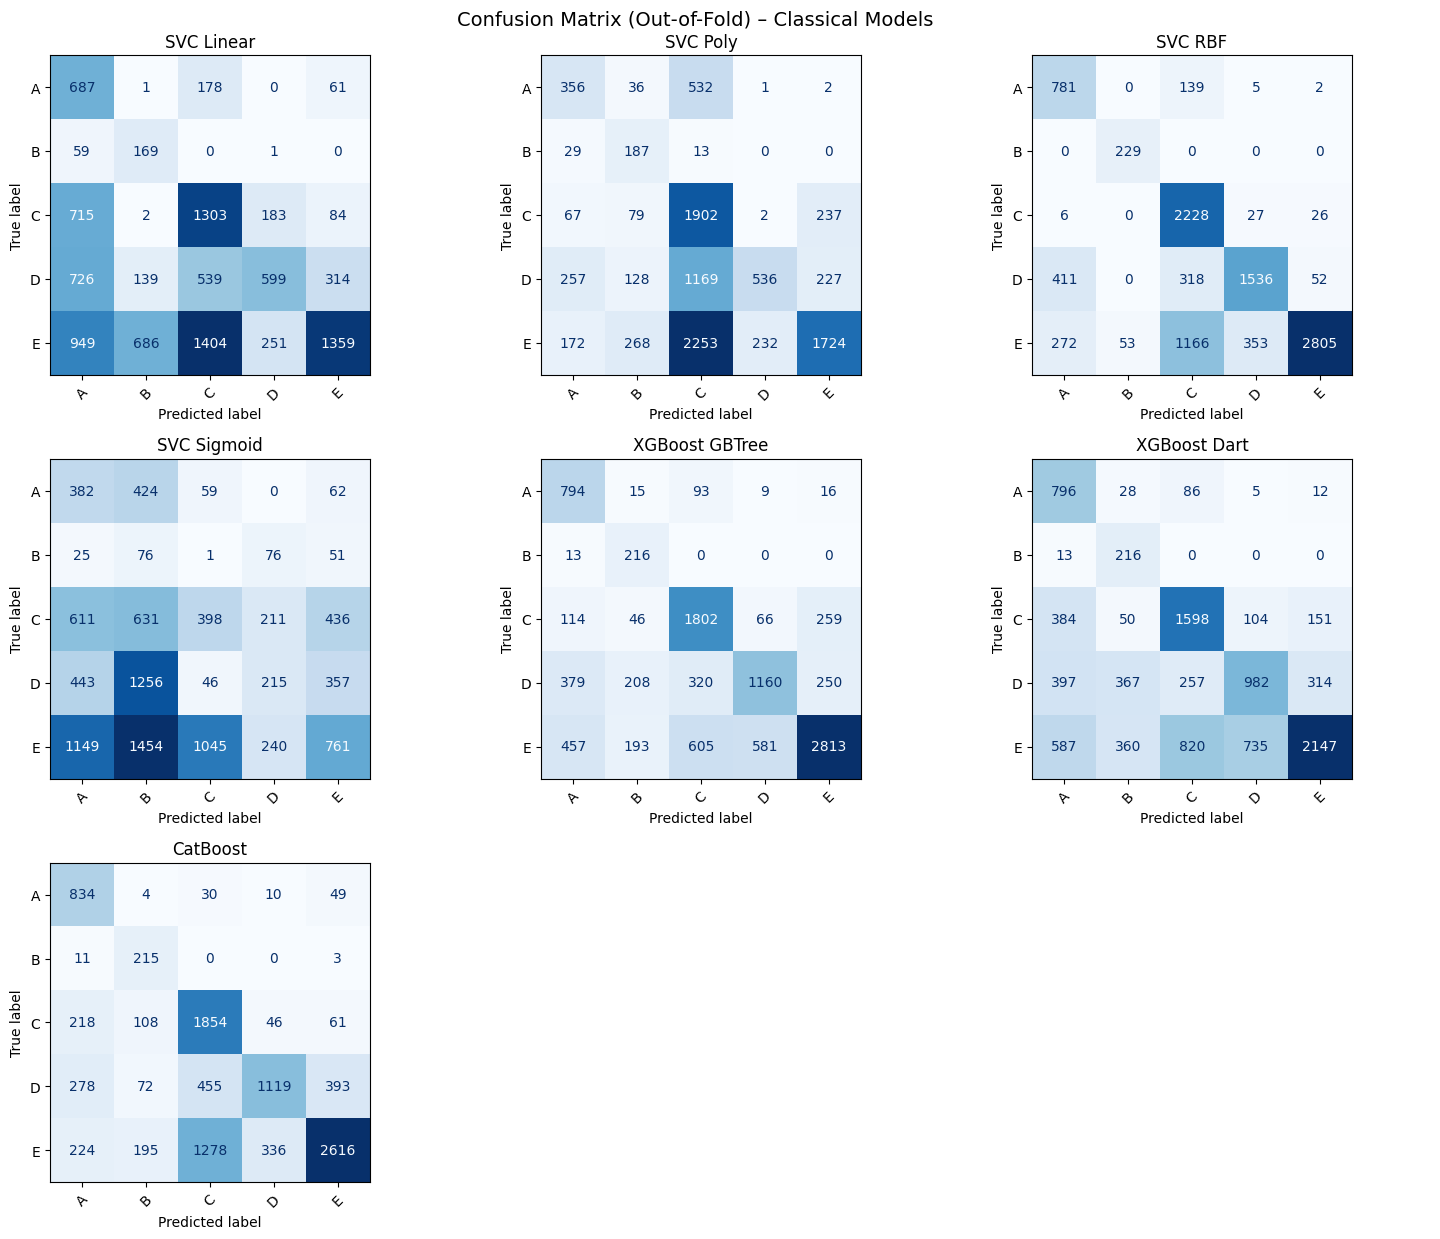

✅ Saved: ./results/confusion_matrix_classical_hpo.png

SVC Linear — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.22      0.74      0.34       927
           B       0.17      0.74      0.28       229
           C       0.38      0.57      0.46      2287
           D       0.58      0.26      0.36      2317
           E       0.75      0.29      0.42      4649

    accuracy                           0.40     10409
   macro avg       0.42      0.52      0.37     10409
weighted avg       0.57      0.40      0.40     10409


SVC Poly — per-class metrics (OOF)
              precision    recall  f1-score   support

           A       0.40      0.38      0.39       927
           B       0.27      0.82      0.40       229
           C       0.32      0.83      0.47      2287
           D       0.70      0.23      0.35      2317
           E       0.79      0.37      0.50      4649

    accuracy                           0.45     10409
   

In [38]:
# ════════════════════════════════════════════════════════════
# 🔢 CONFUSION MATRIX + 📋 PER-CLASS METRICS – semua model (out-of-fold)
# ════════════════════════════════════════════════════════════
# Memakai prediksi out-of-fold (y_true/y_pred) yang dikumpulkan tiap model saat
# cross-validation → mencerminkan generalisasi, bukan performa di data training.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

class_names = list(label_encoder.classes_)
labels = np.arange(len(class_names))

models_cm = [r for r in all_best if "y_true" in r and "y_pred" in r]
if not models_cm:
    print("⚠️  Belum ada y_true/y_pred di all_best. Jalankan ulang sel-sel training dulu.")
else:
    # ── Confusion matrix grid ──
    n = len(models_cm)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, r in zip(axes, models_cm):
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(r["model"])
        ax.tick_params(axis="x", rotation=45)

    for ax in axes[len(models_cm):]:
        ax.axis("off")

    fig.suptitle("Confusion Matrix (Out-of-Fold) – Classical Models", fontsize=14)
    fig.tight_layout()

    os.makedirs("./results", exist_ok=True)
    out_path = "./results/confusion_matrix_classical_hpo.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

    # ── Per-class metrics: classification_report tiap model (OOF best config) ──
    # Pakai laporan yang sudah disimpan evaluate_cv; fallback hitung ulang bila perlu.
    for r in models_cm:
        print()
        print("=" * 60)
        print(f"{r['model']} — per-class metrics (OOF)")
        print("=" * 60)
        if r.get("report_text"):
            print(r["report_text"])
        else:
            print(classification_report(
                r["y_true"], r["y_pred"], labels=labels,
                target_names=class_names, zero_division=0))


### 3.3 Simpan tabel evaluasi

In [39]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_classical_final_hpo.csv', index=True)
print('✅ Saved: ./results/eval_classical_final_hpo.csv')

✅ Saved: ./results/eval_classical_final_hpo.csv


### 3.4 Learning curve (accuracy, precision, recall, f1, log-loss)

📊 Learning curve on N=10409 | CV=5 | sizes=[0.2 0.4 0.6 0.8 1. ]
  ▶ SVC Linear  ({'C': 0.1}) ... done
  ▶ SVC Poly  ({'C': 0.01, 'degree': 2, 'gamma': 'scale'}) ... done
  ▶ SVC RBF  ({'C': 0.05, 'gamma': 'scale'}) ... done
  ▶ SVC Sigmoid  ({'C': 0.1, 'gamma': 'scale', 'coef0': 0}) ... done
  ▶ XGBoost GBTree  ({'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 15, 'reg_alpha': 10, 'reg_lambda': 100, 'gamma': 5}) ... done
  ▶ XGBoost Dart  ({'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 15, 'reg_alpha': 10, 'reg_lambda': 100, 'gamma': 5, 'rate_drop': 0.4, 'skip_drop': 0.5}) ... done
  ▶ CatBoost  ({'iterations': 80, 'depth': 3, 'learning_rate': 0.03, 'l2_leaf_reg': 30, 'random_strength': 5, 'bagging_temperature': 1.0}) ... done
📊 Plot disimpan → ./results/learning_curve_accuracy_hpo.png


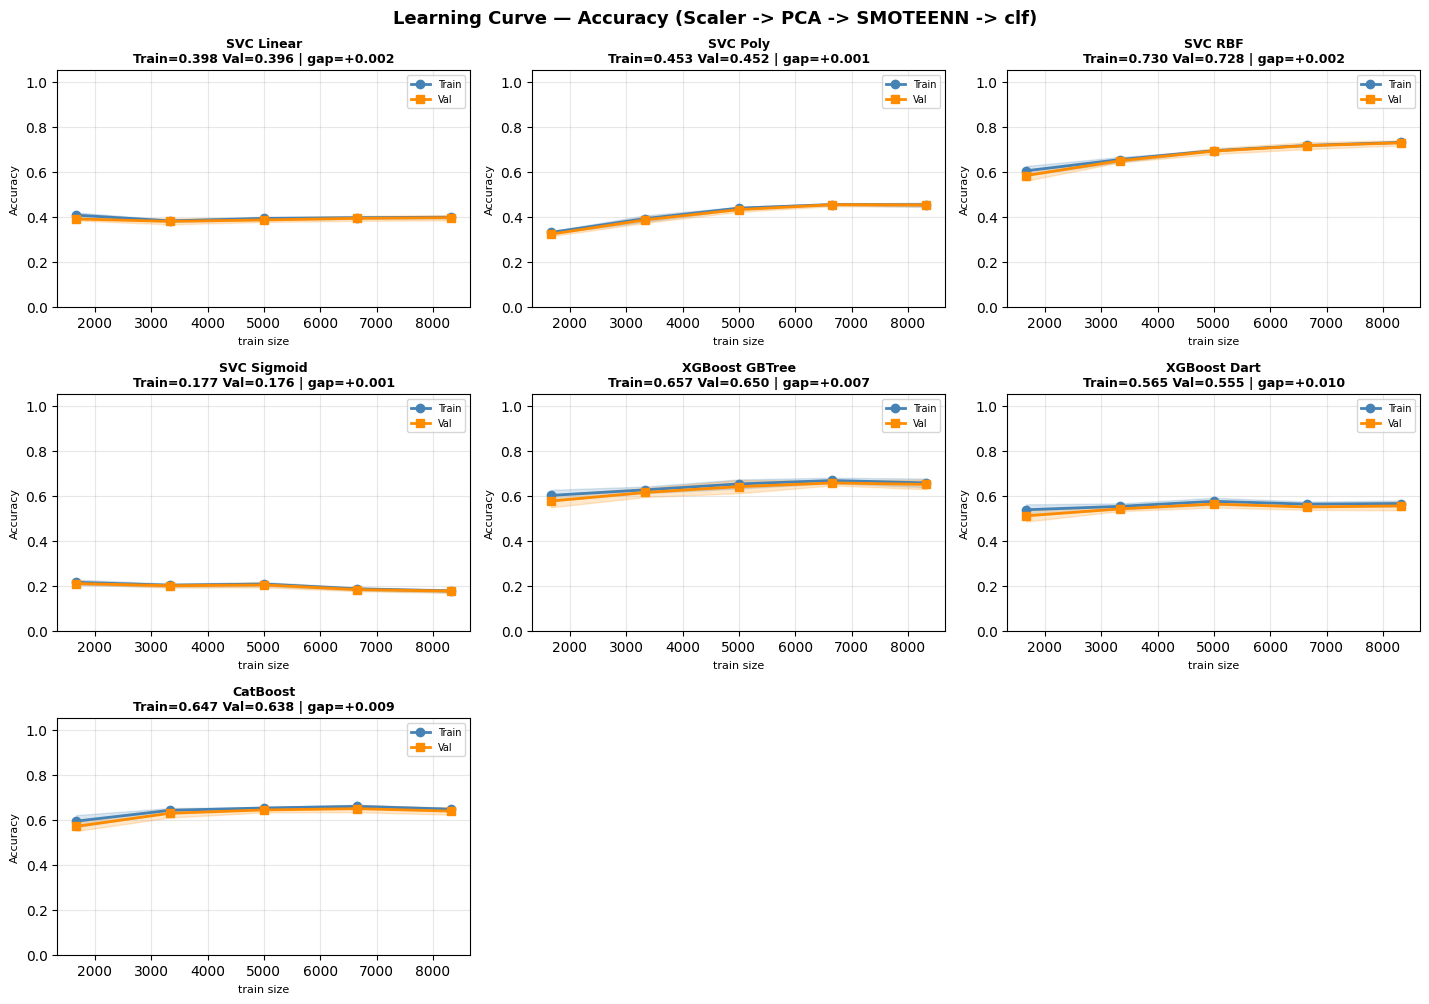

📊 Plot disimpan → ./results/learning_curve_precision_hpo.png


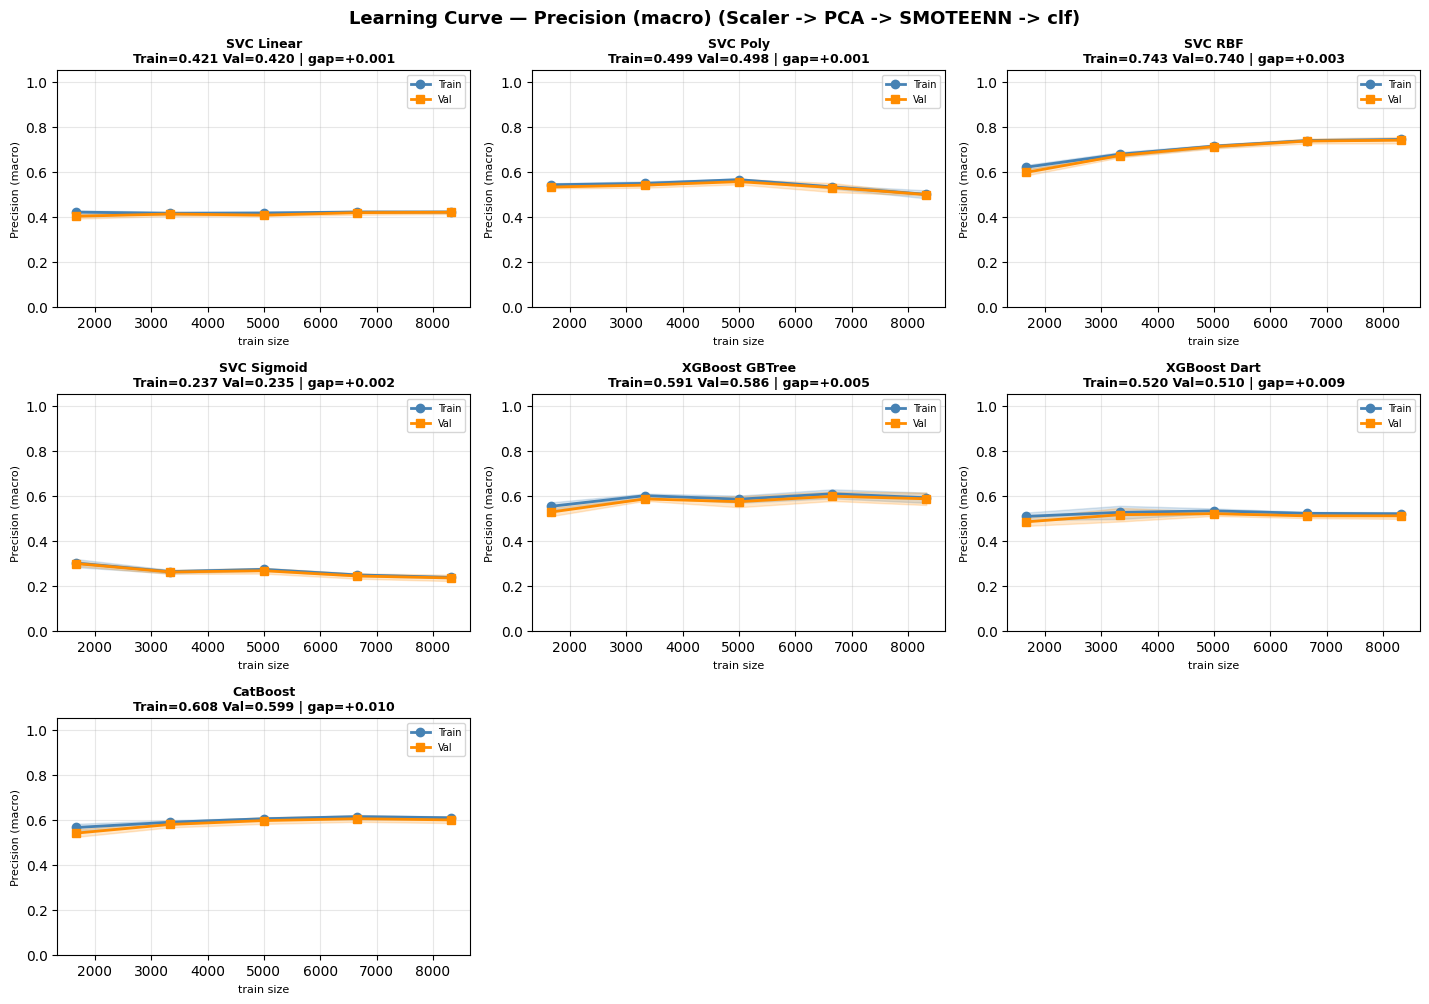

📊 Plot disimpan → ./results/learning_curve_recall_hpo.png


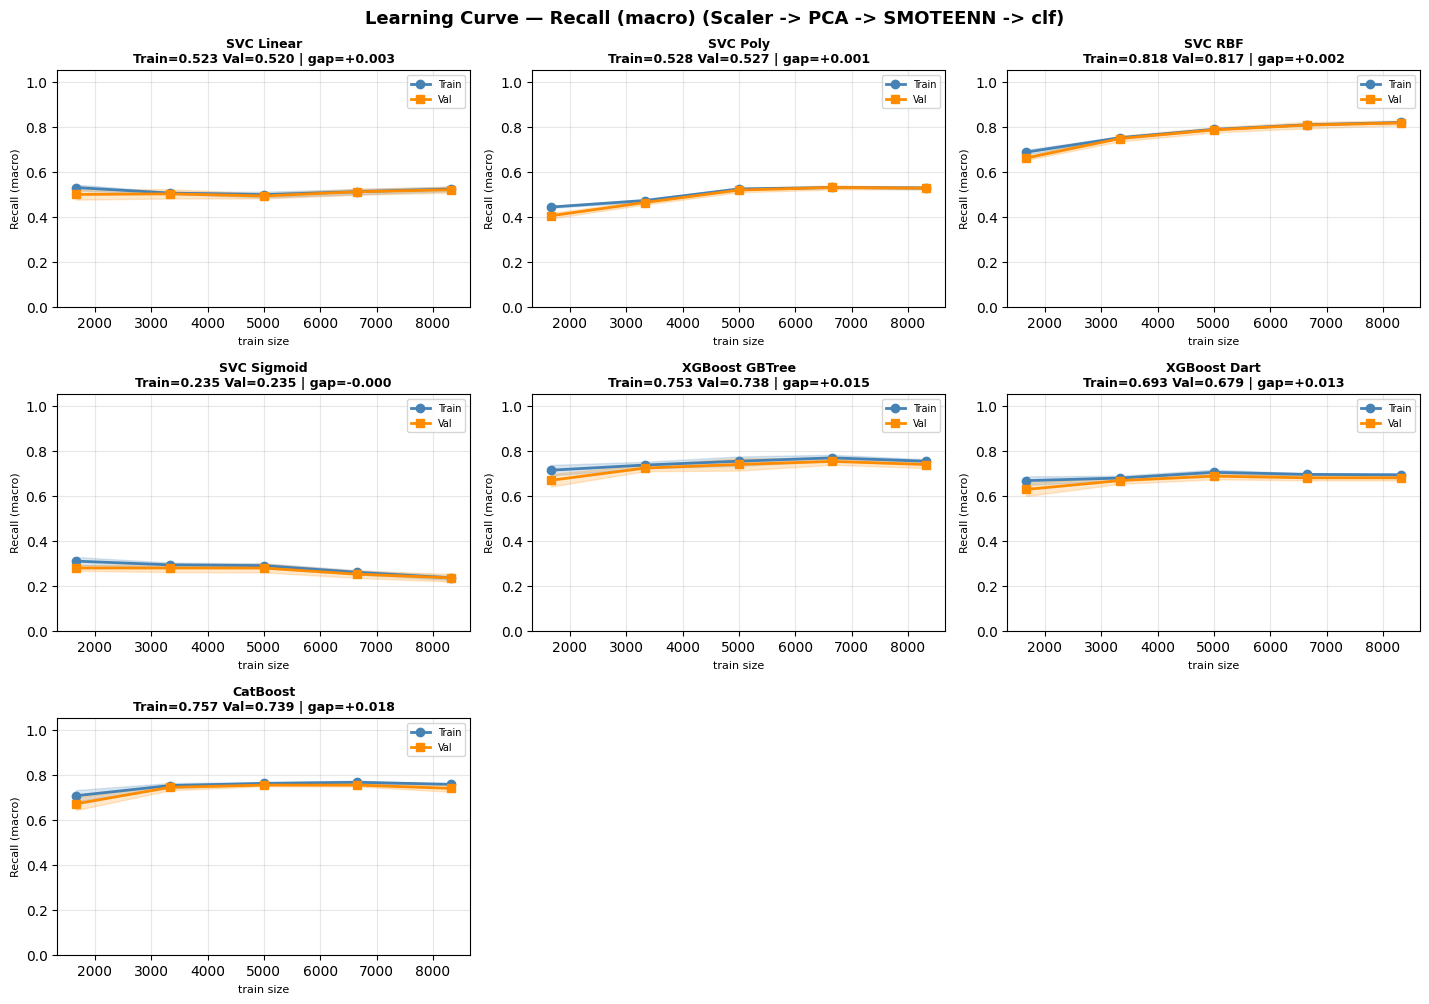

📊 Plot disimpan → ./results/learning_curve_f1_hpo.png


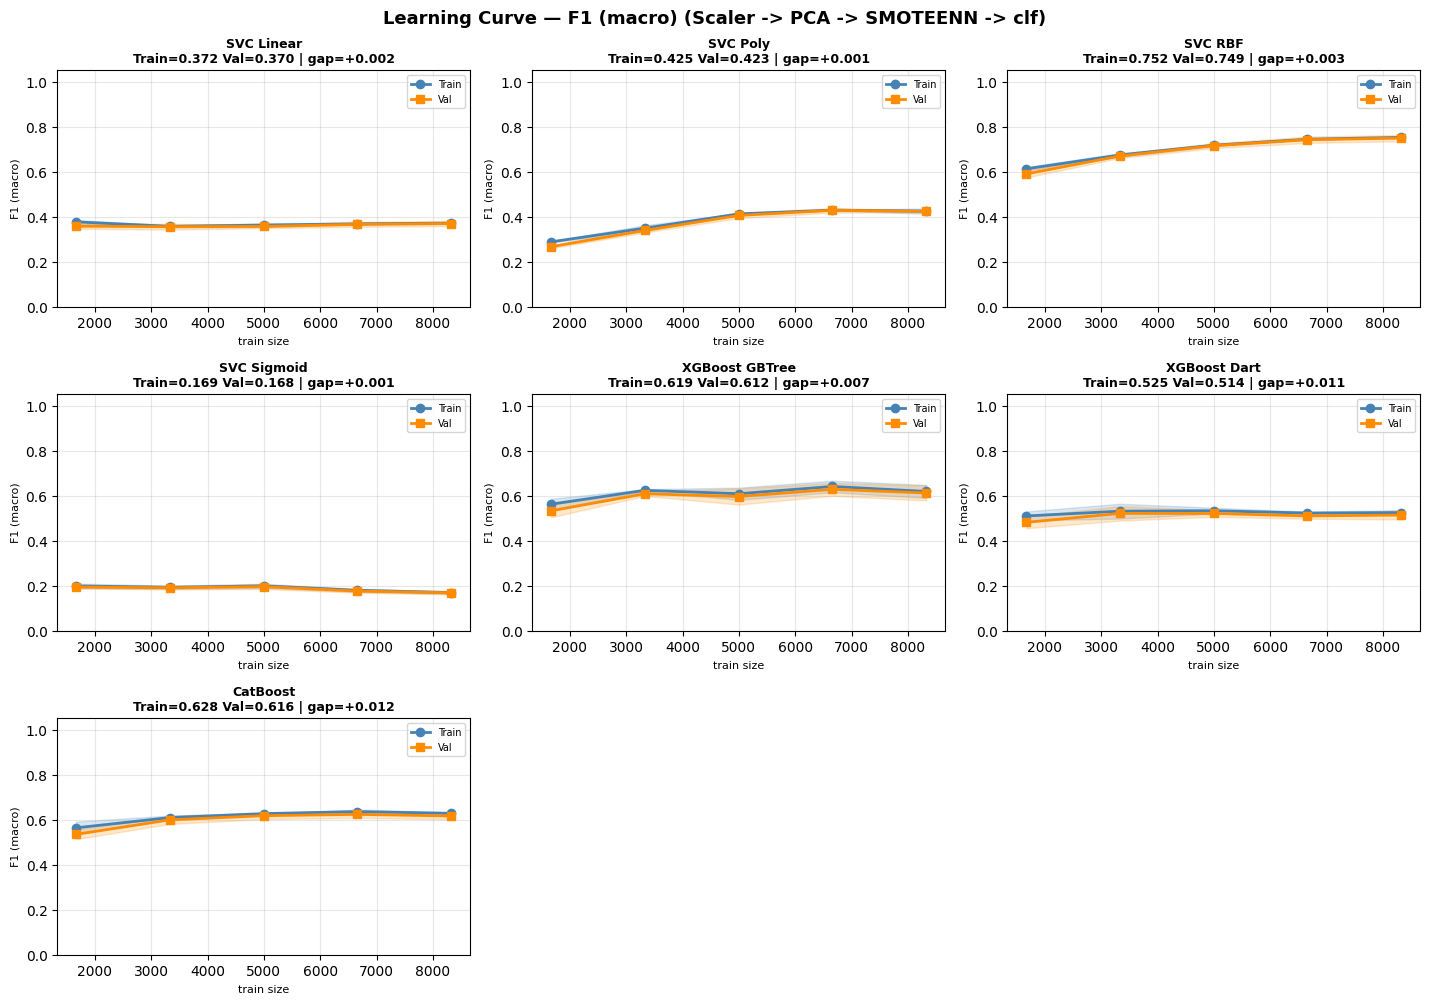

📊 Plot disimpan → ./results/learning_curve_log_loss_hpo.png


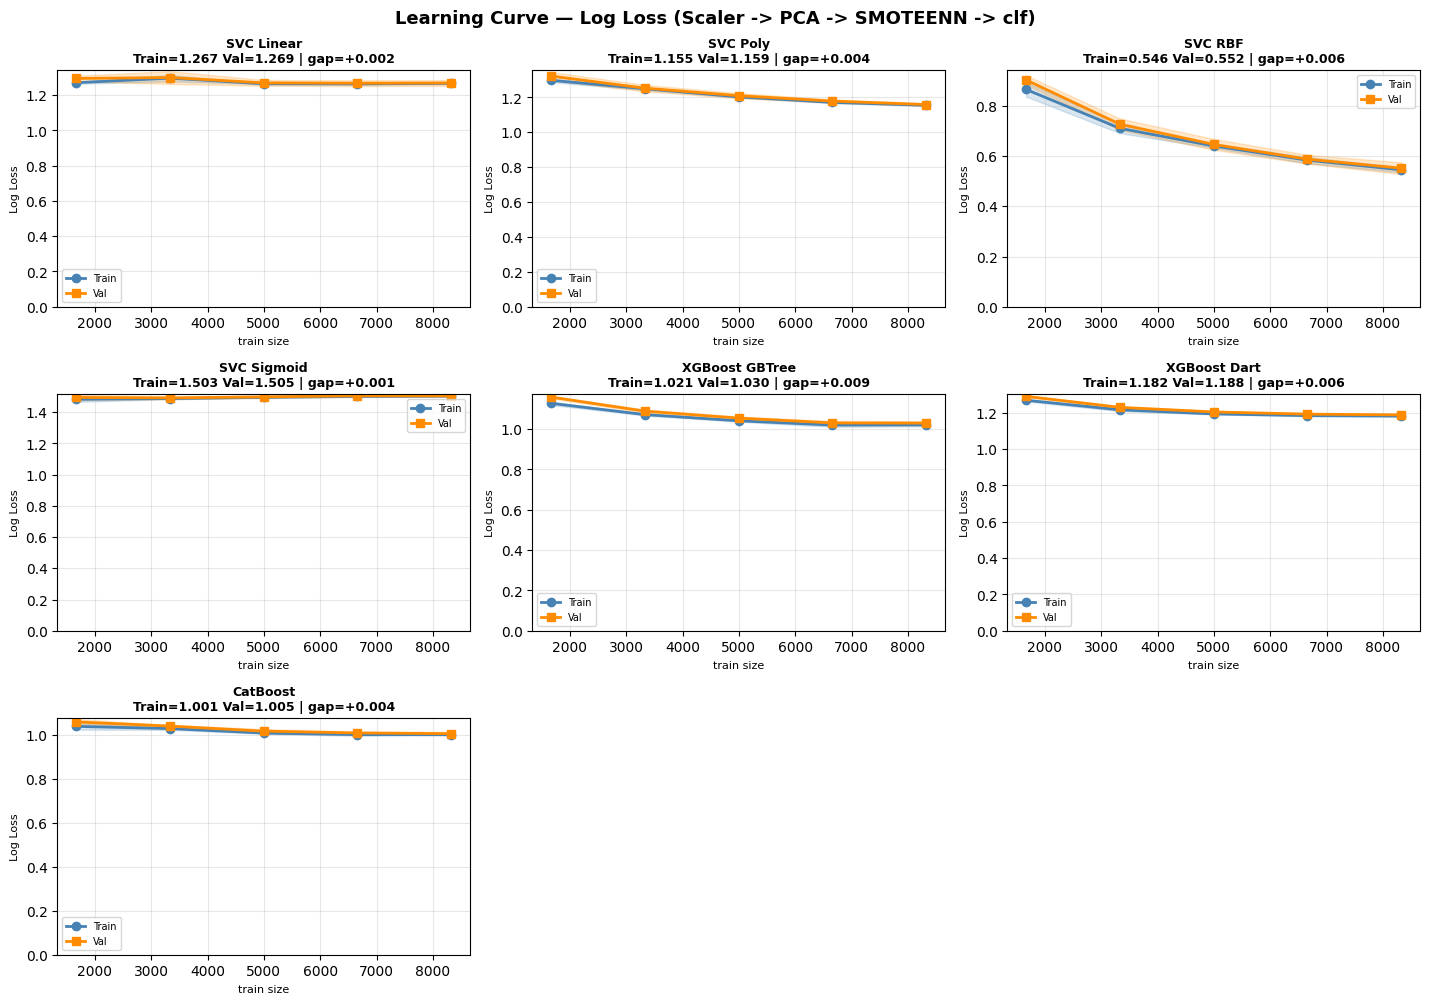

In [40]:
# ════════════════════════════════════════════════════════════
# 📈 Learning Curve — accuracy, precision, recall, f1, log-loss
# ════════════════════════════════════════════════════════════
# Untuk tiap model best: train vs validation pada beberapa ukuran training set,
# memakai pipeline yang SAMA dengan training (Scaler → PCA → SMOTEENN → clf).
# Resampling hanya di subset training tiap fold (no leak); metrik "train" dihitung
# pada subset training ASLI (sebelum resample) supaya gap-nya jujur.
#
# CATATAN PERFORMA:
#   - LC_N = len(X) (full). SVC + probability=True bisa lambat (O(N²)). Turunkan
#     LC_N untuk subsample stratified kalau perlu cepat.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
)

# ── Konfigurasi ───────────────────────────────────────────────────────────────
LC_N           = len(X)                      # subsample stratified (kecilkan utk cepat)
LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)    # 5 titik kurva
LC_CV          = 5                           # CV folds (sama dgn training)
LC_STATE       = 42
_classes       = np.unique(y)

# metric_name -> (fn(y_true, y_pred, y_prob) -> nilai, lower_is_better)
def _m_acc(yt, yp, pp): return accuracy_score(yt, yp)
def _m_prec(yt, yp, pp): return precision_score(yt, yp, average="macro", zero_division=0)
def _m_rec(yt, yp, pp): return recall_score(yt, yp, average="macro", zero_division=0)
def _m_f1(yt, yp, pp): return f1_score(yt, yp, average="macro", zero_division=0)
def _m_loss(yt, yp, pp): return log_loss(yt, pp, labels=_classes)
METRICS = {
    "accuracy":  (_m_acc,  False),
    "precision": (_m_prec, False),
    "recall":    (_m_rec,  False),
    "f1":        (_m_f1,   False),
    "log_loss":  (_m_loss, True),    # ↓ lebih kecil lebih baik
}

# ── Stratified subsample untuk speed ──────────────────────────────────────────
if LC_N < len(X):
    sss = StratifiedShuffleSplit(n_splits=1, train_size=LC_N, random_state=LC_STATE)
    sub_idx, _ = next(sss.split(X, y))
    X_lc, y_lc = X.iloc[sub_idx], y[sub_idx]
else:
    X_lc, y_lc = X, y
print(f"📊 Learning curve on N={len(X_lc)} | CV={LC_CV} | sizes={LC_TRAIN_SIZES}")


def learning_curve_multi(pipe, Xd, yd, train_sizes, cv, state):
    """Satu fit per (fold, size); hitung SEMUA metrik sekaligus.
    Train diukur pada subset training ASLI (pre-resample); val pada fold validasi.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=state)
    out = {m: {"train": [[] for _ in train_sizes], "val": [[] for _ in train_sizes]}
           for m in METRICS}
    sizes_abs = [[] for _ in train_sizes]
    for tr_idx, va_idx in skf.split(Xd, yd):
        Xtr_f, ytr_f = Xd.iloc[tr_idx], yd[tr_idx]
        Xva, yva = Xd.iloc[va_idx], yd[va_idx]
        for si, ts in enumerate(train_sizes):
            n = int(round(ts * len(tr_idx)))
            if n >= len(tr_idx):
                Xs, ys = Xtr_f, ytr_f
            else:
                sub, _ = next(StratifiedShuffleSplit(
                    n_splits=1, train_size=n, random_state=state).split(Xtr_f, ytr_f))
                Xs, ys = Xtr_f.iloc[sub], ytr_f[sub]
            sizes_abs[si].append(len(Xs))
            m = clone(pipe)
            m.fit(Xs, ys)
            # train pada subset ASLI (resampler dilewati saat predict)
            ytr_pred, ytr_prob = m.predict(Xs), m.predict_proba(Xs)
            yva_pred, yva_prob = m.predict(Xva), m.predict_proba(Xva)
            for name, (fn, _) in METRICS.items():
                out[name]["train"][si].append(fn(ys, ytr_pred, ytr_prob))
                out[name]["val"][si].append(fn(yva, yva_pred, yva_prob))
    sizes_mean = [int(np.mean(s)) for s in sizes_abs]
    agg = {}
    for name in METRICS:
        agg[name] = {
            "train_mean": np.array([np.mean(v) for v in out[name]["train"]]),
            "train_std":  np.array([np.std(v)  for v in out[name]["train"]]),
            "val_mean":   np.array([np.mean(v) for v in out[name]["val"]]),
            "val_std":    np.array([np.std(v)  for v in out[name]["val"]]),
        }
    return sizes_mean, agg


# ── Hitung learning curve per model ───────────────────────────────────────────
lc_results = []
for entry in all_best:
    name   = entry["model"]
    params = entry.get("params", {})
    print(f"  ▶ {name}  ({params}) ...", end=" ", flush=True)
    try:
        pipe = make_classical(name, params)
        sizes_mean, agg = learning_curve_multi(pipe, X_lc, y_lc,
                                               LC_TRAIN_SIZES, LC_CV, LC_STATE)
        lc_results.append({"model": name, "sizes": sizes_mean, "agg": agg})
        print("done")
    except Exception as e:
        print(f"FAILED — {type(e).__name__}: {e}")

# ── Plot: SATU figure per metrik (subplot = tiap model) ──────────────────────
metric_names = list(METRICS.keys())
TITLES = {"accuracy": "Accuracy", "precision": "Precision (macro)",
          "recall": "Recall (macro)", "f1": "F1 (macro)", "log_loss": "Log Loss"}
os.makedirs("./results", exist_ok=True)

n_models = len(lc_results)
ncols = min(3, n_models) if n_models else 1
nrows = int(np.ceil(n_models / ncols)) if n_models else 1

for mname in metric_names:
    lower = METRICS[mname][1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.4 * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for ax, r in zip(axes, lc_results):
        ts = r["sizes"]; a = r["agg"][mname]
        ax.plot(ts, a["train_mean"], "o-", color="steelblue", lw=2, label="Train")
        ax.fill_between(ts, a["train_mean"] - a["train_std"], a["train_mean"] + a["train_std"],
                        alpha=0.2, color="steelblue")
        ax.plot(ts, a["val_mean"], "s-", color="darkorange", lw=2, label="Val")
        ax.fill_between(ts, a["val_mean"] - a["val_std"], a["val_mean"] + a["val_std"],
                        alpha=0.2, color="darkorange")
        gap = (a["val_mean"][-1] - a["train_mean"][-1]) if lower else (a["train_mean"][-1] - a["val_mean"][-1])
        ax.set_title(f"{r['model']}\nTrain={a['train_mean'][-1]:.3f} Val={a['val_mean'][-1]:.3f} | gap={gap:+.3f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("train size", fontsize=8); ax.set_ylabel(TITLES[mname], fontsize=8)
        ax.grid(True, alpha=0.3)
        if lower:
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7)
    for ax in axes[n_models:]:
        ax.axis("off")
    fig.suptitle(f"Learning Curve — {TITLES[mname]} (Scaler -> PCA -> SMOTEENN -> clf)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(f"./results/learning_curve_{mname}_hpo.png", dpi=120, bbox_inches="tight")
    print(f"📊 Plot disimpan → ./results/learning_curve_{mname}_hpo.png")
    plt.show()


### 3.5 Selisih (gap) Train vs Val — tabel terpisah per metrik

Satu tabel untuk tiap metrik berisi `Train` (mean ± std), `Val` (mean ± std), `Selisih (Train-Val)`, dan `overfit_gap`. Konvensi `overfit_gap`: **> 0 = indikasi overfit** (skor = Train − Val; `log_loss` = Val − Train, karena loss makin kecil makin baik). Diukur pada fraksi data latih terbesar. Makin besar `overfit_gap`, makin lebar jurang train ↔ val.

In [41]:
# ════════════════════════════════════════════════════════════
# 📋 Gap Train vs Val per metrik (fraksi data latih terbesar)
# ════════════════════════════════════════════════════════════
metric_names = list(METRICS.keys())
TITLES = {"accuracy": "Accuracy", "precision": "Precision (macro)",
          "recall": "Recall (macro)", "f1": "F1 (macro)", "log_loss": "Log Loss"}

gap_tables = {}
for mname in metric_names:
    lower = METRICS[mname][1]
    rows = []
    for r in lc_results:
        a = r["agg"][mname]
        train_m, train_s = float(a["train_mean"][-1]), float(a["train_std"][-1])
        val_m, val_s = float(a["val_mean"][-1]), float(a["val_std"][-1])
        selisih = train_m - val_m
        overfit_gap = (val_m - train_m) if lower else (train_m - val_m)
        rows.append({"Model": r["model"],
                     "Train": train_m, "Train_std": train_s,
                     "Val": val_m, "Val_std": val_s,
                     "Selisih (Train-Val)": selisih, "overfit_gap": overfit_gap})
    df = pd.DataFrame(rows)
    gap_tables[mname] = df
    df.to_csv(f"./results/learning_curve_gap_{mname}_hpo.csv", index=False)

# Tampilkan satu tabel per metrik (overfit_gap diwarnai; makin merah makin overfit).
for mname in metric_names:
    df = gap_tables[mname]
    disp = pd.DataFrame({"Model": df["Model"]})
    disp["Train"] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(df["Train"], df["Train_std"])]
    disp["Val"]   = [f"{m:.4f} ± {s:.4f}" for m, s in zip(df["Val"], df["Val_std"])]
    disp["Selisih (Train-Val)"] = df["Selisih (Train-Val)"]
    disp["overfit_gap"] = df["overfit_gap"]
    print("=" * 60)
    print(f"Metrik: {TITLES[mname]}")
    display(disp.style.format({"Selisih (Train-Val)": "{:.4f}", "overfit_gap": "{:.4f}"})
            .background_gradient(cmap="Reds", subset=["overfit_gap"]))
print("✅ Saved: ./results/learning_curve_gap_*_hpo.csv")


Metrik: Accuracy


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.3976 ± 0.0050,0.3955 ± 0.0117,0.0021,0.0021
1,SVC Poly,0.4528 ± 0.0094,0.4520 ± 0.0067,0.0008,0.0008
2,SVC RBF,0.7301 ± 0.0030,0.7281 ± 0.0116,0.0019,0.0019
3,SVC Sigmoid,0.1767 ± 0.0062,0.1760 ± 0.0078,0.0007,0.0007
4,XGBoost GBTree,0.6566 ± 0.0193,0.6498 ± 0.0214,0.0068,0.0068
5,XGBoost Dart,0.5649 ± 0.0135,0.5546 ± 0.0196,0.0103,0.0103
6,CatBoost,0.6467 ± 0.0037,0.6377 ± 0.0158,0.0090,0.0090


Metrik: Precision (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.4209 ± 0.0045,0.4195 ± 0.0079,0.0013,0.0013
1,SVC Poly,0.4992 ± 0.0178,0.4984 ± 0.0047,0.0008,0.0008
2,SVC RBF,0.7431 ± 0.0027,0.7397 ± 0.0143,0.0034,0.0034
3,SVC Sigmoid,0.2369 ± 0.0035,0.2345 ± 0.0140,0.0024,0.0024
4,XGBoost GBTree,0.5907 ± 0.0227,0.5860 ± 0.0277,0.0047,0.0047
5,XGBoost Dart,0.5195 ± 0.0071,0.5103 ± 0.0134,0.0092,0.0092
6,CatBoost,0.6083 ± 0.0056,0.5988 ± 0.0142,0.0095,0.0095


Metrik: Recall (macro)


...

Metrik: F1 (macro)


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,0.3715 ± 0.0047,0.3696 ± 0.0115,0.0019,0.0019
1,SVC Poly,0.4246 ± 0.0118,0.4232 ± 0.0035,0.0014,0.0014
2,SVC RBF,0.7522 ± 0.0025,0.7490 ± 0.0139,0.0032,0.0032
3,SVC Sigmoid,0.1693 ± 0.0061,0.1684 ± 0.0077,0.0009,0.0009
4,XGBoost GBTree,0.6186 ± 0.0289,0.6118 ± 0.0334,0.0069,0.0069
5,XGBoost Dart,0.5248 ± 0.0110,0.5139 ± 0.0196,0.0109,0.0109
6,CatBoost,0.6280 ± 0.0044,0.6161 ± 0.0148,0.0119,0.0119


Metrik: Log Loss


,Model,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,1.2672 ± 0.0036,1.2694 ± 0.0165,-0.0022,0.0022
1,SVC Poly,1.1553 ± 0.0051,1.1592 ± 0.0081,-0.0039,0.0039
2,SVC RBF,0.5458 ± 0.0101,0.5521 ± 0.0235,-0.0064,0.0064
3,SVC Sigmoid,1.5034 ± 0.0038,1.5047 ± 0.0054,-0.0014,0.0014
4,XGBoost GBTree,1.0213 ± 0.0070,1.0299 ± 0.0098,-0.0086,0.0086
5,XGBoost Dart,1.1820 ± 0.0033,1.1884 ± 0.0056,-0.0064,0.0064
6,CatBoost,1.0006 ± 0.0020,1.0051 ± 0.0077,-0.0045,0.0045


✅ Saved: ./results/learning_curve_gap_*_hpo.csv
